<a href="https://colab.research.google.com/github/ysn9vq-gmu/rqe_tutorials/blob/main/ls_rls.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tutorial to Least Squares and Recursive Least Squares applied to Runner Timing Simulation

In [ ]:
from IPython.display import display, HTML

display(HTML("""
<style>
.jp-RenderedHTMLCommon {
    max-width: 60vw;
    line-height: 1.5;
}
</style>
"""))

## Runner Performance Modeling with Least Squares

In this tutorial, we will use a simulation to explore how Least Squares (LS) and Recursive Least Squares (RLS) can be applied to estimate a runner's performance.

Imagine a scenario where a runner trains daily, and multiple coaches record their sprint times using stopwatches. In addition to the runner's inherent ability (baseline performance), their timing is also affected by environmental factors, primarily wind. Each coach might also have a slight bias in their stopwatch readings.

Our goal is to estimate the runner's **baseline performance** (their time under normal, windless conditions) and the **impact of wind** on their speed, and potentially **each coach's measurement bias**. This model will help us track the runner's improvement and understand external factors.

We define the observed time ($T$) for a run as:

$$T = T_{baseline} + W \cdot V_{wind} + B_{coach} + \epsilon$$

Where:
*   $T_{baseline}$ is the runner's true baseline time (what we want to estimate).
*   $W$ is a coefficient representing the wind's effect on time (e.g., seconds per m/s wind speed).
*   $V_{wind}$ is the measured wind speed.
*   $B_{coach}$ is the bias of the specific coach measuring the time.
*   $\epsilon$ is random measurement error (noise).

This problem can be formulated as a linear system suitable for Least Squares estimation.

### Formulating the Runner Timing Problem as a Linear System (Ax=B)

To apply Least Squares, we transform our runner timing model into the standard linear system form:

$$\mathbf{A} \mathbf{x} = \mathbf{b}$$

Where:
*   $\mathbf{x}$ is the vector of unknown parameters we want to estimate.
*   $\mathbf{A}$ is the design matrix, containing the known coefficients (wind speed, coach indicators).
*   $\mathbf{b}$ is the vector of observed measurements (runner's recorded times).

Let's assume our unknown parameter vector $\mathbf{x}$ consists of:

$$\mathbf{x} = \begin{bmatrix} T_{baseline} \\ W \\ B_{coach1} \\ B_{coach2} \\ \vdots \end{bmatrix}$$

For each measurement (a run timed by a specific coach under certain wind conditions), we can form a row in the $\mathbf{A}$ matrix and an entry in the $\mathbf{b}$ vector.

For example, if Coach 1 times a run with wind speed $V_{wind}$, the corresponding row in $\mathbf{A}$ would be `[1, V_wind, 1, 0, ...]`, and the entry in $\mathbf{b}$ would be the recorded time. The `1` for $T_{baseline}$ means it always contributes to the total time. The `1` for $B_{coach1}$ means that this specific coach's bias is active for this measurement. If Coach 2 timed it, that row would be `[1, V_wind, 0, 1, ...]`, and so on.

Each row in $\mathbf{A}$ represents a single observation (a timed run), and each column corresponds to a parameter in $\mathbf{x}$.

This setup allows us to leverage the power of linear algebra to find the best-fit estimates for our runner's performance and environmental factors.

#### Python imports
Prior to beginning this jupyter-notebook tutorial, we can include some python imports.

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Simulation Parameters ---
np.random.seed(42)

# True underlying parameters for the runner's performance model
true_baseline_time = 10.0 # seconds for a specific distance under ideal conditions
true_wind_effect_coeff = -0.1 # seconds per m/s (negative means tailwind speeds up, headwind slows down)
true_coach_biases = {
    'Coach A': 0.1,  # Coach A tends to be 0.1 seconds slow
    'Coach B': -0.05, # Coach B tends to be 0.05 seconds fast
    'Coach C': 0.0   # Coach C is unbiased
}

num_runs_per_day = 5
num_coaches = len(true_coach_biases)
coach_names = list(true_coach_biases.keys())
num_days_to_simulate = 50 # Simulate data for 50 days

# --- Generate daily simulated data ---
def generate_daily_data(day_number, true_baseline, true_wind_effect_coeff, true_coach_biases, num_runs, coach_names):
    observed_times = []
    wind_speeds = []
    coach_indices = []

    for _ in range(num_runs):
        # Simulate wind speed (e.g., from -5 m/s (headwind) to +5 m/s (tailwind))
        wind = np.random.uniform(-5, 5)
        # Randomly assign a coach for this run
        coach_name = np.random.choice(coach_names)
        coach_bias = true_coach_biases[coach_name]

        # True time = baseline + wind_effect * wind_speed + coach_bias + noise
        noise = np.random.normal(0, 0.05) # Small measurement noise
        observed_time = (true_baseline +
                         true_wind_effect_coeff * wind +
                         coach_bias +
                         noise)

        observed_times.append(observed_time)
        wind_speeds.append(wind)
        coach_indices.append(coach_name)

    df_day = pd.DataFrame({
        'day': day_number,
        'wind_speed': wind_speeds,
        'coach': coach_indices,
        'observed_time': observed_times
    })
    return df_day

# Generate data for multiple days
all_daily_data = []
for day in range(1, num_days_to_simulate + 1):
    all_daily_data.append(generate_daily_data(day, true_baseline_time, true_wind_effect_coeff, true_coach_biases, num_runs_per_day, coach_names))

df_all_data = pd.concat(all_daily_data, ignore_index=True)

print(f"Simulated Data for {num_days_to_simulate} Days (first 5 rows):")
display(df_all_data.head())

# --- Construct A and b for a given DataFrame ---
def construct_A_b(df, coach_names):
    num_params = 1 + 1 + len(coach_names) # Baseline, Wind Effect, Coach Biases
    A = np.zeros((len(df), num_params))
    b = df['observed_time'].values.reshape(-1, 1)

    # Map coach names to column indices
    # Baseline is index 0, Wind Effect is index 1, Coaches start from index 2
    coach_to_idx = {name: i + 2 for i, name in enumerate(coach_names)}

    for local_idx, (original_idx, row) in enumerate(df.iterrows()): # Use local_idx for A
        A[local_idx, 0] = 1 # Coefficient for T_baseline
        A[local_idx, 1] = row['wind_speed'] # Coefficient for W (wind effect)
        A[local_idx, coach_to_idx[row['coach']]] = 1 # Coefficient for B_coach

    # Define the parameter vector 'x' for context
    param_names = ['T_baseline', 'W'] + [f'B_{c}' for c in coach_names]

    return A, b, param_names

# Example for Day 1 (as previously)
df_day1 = df_all_data[df_all_data['day'] == 1]
A_day1, b_day1, param_names = construct_A_b(df_day1, coach_names)

print("\nDesign Matrix A (Day 1, first 3 rows):\n", A_day1[:3])
print("\nObservation Vector b (Day 1, first 3 rows):\n", b_day1[:3].flatten())
print("\nParameter Names in x:\n", param_names)


Simulated Data for 50 Days (first 5 rows):


,day,wind_speed,coach,observed_time
0,1,-1.254599,Coach A,10.252647
1,1,0.968502,Coach B,9.822378
2,1,-3.440055,Coach C,10.243457
3,1,-3.571332,Coach C,10.332493
4,1,-4.794155,Coach B,10.441070



Design Matrix A (Day 1, first 3 rows):
 [[ 1.         -1.25459881  1.          0.          0.        ]
 [ 1.          0.96850158  0.          1.          0.        ]
 [ 1.         -3.4400548   0.          0.          1.        ]]

Observation Vector b (Day 1, first 3 rows):
 [10.25264704  9.82237835 10.24345734]

Parameter Names in x:
 ['T_baseline', 'W', 'B_Coach A', 'B_Coach B', 'B_Coach C']


## Introduction to Least Squares

### Least Squares Background and Formulation

Least Squares (LS) is a powerful and widely used optimization technique to find the 'best-fit' line or curve for a dataset. It achieves this by minimizing the sum of the squared differences (also known as residuals) between the observed data points and the values predicted by our model. The core idea is that smaller squared errors mean a better fit of our model to the data.

Mathematically, for a linear system $\mathbf{A}\mathbf{x} = \mathbf{b}$, where we want to find the unknown parameter vector $\mathbf{x}$, the Least Squares solution $\hat{\mathbf{x}}$ is defined as the $\mathbf{x}$ that minimizes the following objective function:

$$ \hat{\mathbf{x}} = \underset{\mathbf{x}}{\operatorname{argmin}} \|\mathbf{A}\mathbf{x} - \mathbf{b}\|_2^2 $$

This optimization problem has a closed-form solution, which is derived by taking the derivative of the objective function with respect to $\mathbf{x}$ and setting it to zero. The resulting solution is the famous Normal Equations:

$$ \mathbf{A}^T \mathbf{A} \hat{\mathbf{x}} = \mathbf{A}^T \mathbf{b} $$

Solving for $\hat{\mathbf{x}}$ gives us the Least Squares estimate:

$$ \hat{\mathbf{x}} = (\mathbf{A}^T \mathbf{A})^{-1} \mathbf{A}^T \mathbf{b} $$

This solution provides the Moore-Penrose pseudo-inverse of $\mathbf{A}$, effectively giving us the $\mathbf{x}$ that best satisfies the overdetermined system of equations.

### Least Squares for Runner Timing

Given our runner timing problem formulated as $\mathbf{A}\mathbf{x}=\mathbf{b}$, we can directly apply the Least Squares solution to estimate the runner's baseline, wind effect, and coach biases for a single set of observations (e.g., a single day's worth of runs). The solution is:

$$ \mathbf{x}_{LS} = (\mathbf{A}^T \mathbf{A})^{-1} \mathbf{A}^T \mathbf{b} $$

It's important to note that this basic LS formulation provides an estimate based solely on the current set of data. If we were to collect new data points, we would re-run the entire calculation. This approach does not inherently account for changes over time or incorporate information from past estimates in a recursive manner, which we will explore later with Recursive Least Squares.

In [2]:
# Apply Least Squares to Day 1 data

# Ensure A^T A is invertible. If not, np.linalg.lstsq can handle it better.
# For a tutorial, we'll assume it's well-conditioned for now.

if np.linalg.det(A_day1.T @ A_day1) == 0:
    print("Warning: (A^T A) is singular, LS solution might not be unique or stable. Using np.linalg.lstsq.")
    x_ls, residuals, rank, s = np.linalg.lstsq(A_day1, b_day1, rcond=None)
else:
    x_ls = np.linalg.inv(A_day1.T @ A_day1) @ A_day1.T @ b_day1

print("Least Squares Estimates for Day 1:")
for i, param in enumerate(param_names):
    print(f"{param}: {x_ls[i, 0]:.4f}")

print("\nTrue Parameters:")
print(f"T_baseline: {true_baseline_time}")
print(f"W: {true_wind_effect_coeff}")
for coach, bias in true_coach_biases.items():
    print(f"B_{coach}: {bias}")

# Calculate estimation error for Day 1
true_params = np.array([
    true_baseline_time,
    true_wind_effect_coeff
] + list(true_coach_biases.values())).reshape(-1, 1)

error_ls = np.linalg.norm(x_ls - true_params)
print(f"\nLS Estimation Error (Day 1): {error_ls:.4f}")


Least Squares Estimates for Day 1:
T_baseline: 20.4962
W: -0.8759
B_Coach A: -0.2665
B_Coach B: -10.7049
B_Coach C: -2.9491

True Parameters:
T_baseline: 10.0
W: -0.1
B_Coach A: 0.1
B_Coach B: -0.05
B_Coach C: 0.0

LS Estimation Error (Day 1): 15.2686


## Batch Least Squares for Runner Timing

While the single-day LS provides an immediate estimate, it's often noisy and inaccurate due to limited data. What if we want to use *all* the past data to get a more robust estimate of the runner's baseline ability, wind effect, and coach biases?

This is where **Batch Least Squares** comes in. The idea is to collect all available observations up to a certain point in time and then process them together to obtain a single, comprehensive estimate. This approach assumes that the underlying parameters (runner's baseline, wind effect, coach biases) are relatively constant over the batch period.

Suppose we collect $K$ observations (timed runs) over several days. Each observation $k$ (which is a single row in our `A` matrix and a single entry in `b`) contributes to a system of equations:

$$ T_k = T_{baseline} + W \cdot V_{wind,k} + B_{coach,k} + \epsilon_k $$

Our goal then becomes to solve this optimization problem, minimizing the sum of squared residuals across *all* $K$ observations:

$$ \hat{\mathbf{x}} = \underset{\mathbf{x}}{\operatorname{argmin}} \sum_{k=1}^{K} \left\| \mathbf{A}_k \mathbf{x} - \mathbf{b}_k \right\|_2^2 $$

Here, $\mathbf{A}_k$ represents the row of the design matrix corresponding to the $k$-th observation, and $\mathbf{b}_k$ is the $k$-th observed time.

### Batch Least Squares Linear Algebra

The sum of squared norms can be equivalently written using 'stacked' matrices:

$$ \sum_{k=1}^{K} \left\| \mathbf{A}_k \mathbf{x} - \mathbf{b}_k \right\|_2^2 = \left\| \mathbf{A}_{stack} \mathbf{x} - \mathbf{b}_{stack} \right\|_2^2 $$

Where $\mathbf{A}_{stack}$ and $\mathbf{b}_{stack}$ are formed by vertically concatenating all individual observation matrices and vectors:

$$ \mathbf{A}_{stack} = \begin{bmatrix} \mathbf{A}_1 \\ \mathbf{A}_2 \\ \vdots \\ \mathbf{A}_K \end{bmatrix} \quad \text{and} \quad \mathbf{b}_{stack} = \begin{bmatrix} \mathbf{b}_1 \\ \mathbf{b}_2 \\ \vdots \\ \mathbf{b}_K \end{bmatrix} $$

Each $\mathbf{A}_k$ is a $1 \times N$ row vector (where $N$ is the number of parameters, e.g., baseline, wind, coaches), and $\mathbf{b}_k$ is a $1 \times 1$ scalar (the observed time). Thus, if we have $K$ observations:

*   $\mathbf{A}_{stack}$ will have dimensions $K \times N$.
*   $\mathbf{b}_{stack}$ will have dimensions $K \times 1$.

The number of parameters $N$ in our runner timing example is $1$ (baseline) + $1$ (wind effect) + number of coaches.

This transformation converts the sum of individual least squares problems into a single, larger least squares problem, which can then be solved using the standard Normal Equations.

#### Proof of Equivalence for Sum of Squared Norms and Stacked Matrices

Let's clarify why the expression $\sum_{k=1}^{K} \left\| \mathbf{A}_k \mathbf{x} - \mathbf{b}_k \right\|_2^2$ is equivalent to $\left\| \mathbf{A}_{stack} \mathbf{x} - \mathbf{b}_{stack} \right\|_2^2$.

Recall that the squared Euclidean norm of a vector $\mathbf{v}$ is given by $ \|\mathbf{v}\|_2^2 = \mathbf{v}^T \mathbf{v} = \sum v_i^2 $. In our case, each term $(\mathbf{A}_k \mathbf{x} - \mathbf{b}_k)$ is a scalar, representing the residual $e_k$ for the $k$-th observation. So, the sum of squared norms can be written as:

$$ \sum_{k=1}^{K} \left\| \mathbf{A}_k \mathbf{x} - \mathbf{b}_k \right\|_2^2 = \sum_{k=1}^{K} (\mathbf{A}_k \mathbf{x} - \mathbf{b}_k)^2 = e_1^2 + e_2^2 + \dots + e_K^2 $$

Now, let's consider the stacked matrices:

$$ \mathbf{A}_{stack} = \begin{bmatrix} \mathbf{A}_1 \\ \mathbf{A}_2 \\ \vdots \\ \mathbf{A}_K \end{bmatrix} \quad \text{and} \quad \mathbf{b}_{stack} = \begin{bmatrix} \mathbf{b}_1 \\ \mathbf{b}_2 \\ \vdots \\ \mathbf{b}_K \end{bmatrix} $$

When we compute the product $\mathbf{A}_{stack} \mathbf{x}$, we get a column vector:

$$ \mathbf{A}_{stack} \mathbf{x} = \begin{bmatrix} \mathbf{A}_1 \mathbf{x} \\ \mathbf{A}_2 \mathbf{x} \\ \vdots \\ \mathbf{A}_K \mathbf{x} \end{bmatrix} $$

The residual vector for the stacked system is then:

$$ \mathbf{A}_{stack} \mathbf{x} - \mathbf{b}_{stack} = \begin{bmatrix} \mathbf{A}_1 \mathbf{x} \\ \mathbf{A}_2 \mathbf{x} \\ \vdots \\ \mathbf{A}_K \mathbf{x} \end{bmatrix} - \begin{bmatrix} \mathbf{b}_1 \\ \mathbf{b}_2 \\ \vdots \\ \mathbf{b}_K \end{bmatrix} = \begin{bmatrix} \mathbf{A}_1 \mathbf{x} - \mathbf{b}_1 \\ \mathbf{A}_2 \mathbf{x} - \mathbf{b}_2 \\ \vdots \\ \mathbf{A}_K \mathbf{x} - \mathbf{b}_K \end{bmatrix} = \begin{bmatrix} e_1 \\ e_2 \\ \vdots \\ e_K \end{bmatrix} $$

Let's call this stacked residual vector $\mathbf{e}_{stacked}$. Taking its squared Euclidean norm, we get:

$$ \left\| \mathbf{A}_{stack} \mathbf{x} - \mathbf{b}_{stack} \right\|_2^2 = \|\mathbf{e}_{stacked}\|_2^2 = e_1^2 + e_2^2 + \dots + e_K^2 $$

By comparing the two final expressions, we can clearly see that:

$$ \sum_{k=1}^{K} \left\| \mathbf{A}_k \mathbf{x} - \mathbf{b}_k \right\|_2^2 = \left\| \mathbf{A}_{stack} \mathbf{x} - \mathbf{b}_{stack} \right\|_2^2 $$

This equivalence is fundamental for reformulating multiple individual least squares problems into a single, larger batch problem.

Which then results in the familiar LS formulation for the stacked system:

$$ \hat{\mathbf{x}} = (\mathbf{A}_{stack}^T \mathbf{A}_{stack})^{-1} \mathbf{A}_{stack}^T \mathbf{b}_{stack} $$

Alternatively, this can also be expressed as the sum of individual contributions:

$$ \hat{\mathbf{x}} = \left( \sum_{k=1}^{K} \mathbf{A}_k^T \mathbf{A}_k \right)^{-1} \left( \sum_{k=1}^{K} \mathbf{A}_k^T \mathbf{b}_k \right) $$

Where:
*   $\sum_{k=1}^{K} \mathbf{A}_k^T \mathbf{A}_k$ is an $N \times N$ matrix.
*   $\sum_{k=1}^{K} \mathbf{A}_k^T \mathbf{b}_k$ is an $N \times 1$ vector.

This formulation is crucial because it highlights how each new observation contributes to updating the overall sum, which will be fundamental for understanding Recursive Least Squares later.

### Batch Least Squares for Runner Timing Simulation

Below, we will extend our simulation to multiple days. For each day, we generate a new set of runs, and then we will apply batch least squares by accumulating all observations (rows of $\mathbf{A}$ and entries of $\mathbf{b}$) from all days up to the current point. This allows us to see how the parameter estimates converge as more data becomes available.

A key concern for this batch approach is its increasing memory and computation costs because the stacked $\mathbf{A}$ and $\mathbf{b}$ matrices grow with each incoming observation. If desired, the function can be manipulated to only keep a certain number of samples by throwing away the oldest past examples and updating the stacked matrices with new ones, effectively creating a 'sliding window' batch LS. However, for this tutorial, we will accumulate all data.

First, let's simulate data for several days.


Final Batch LS Estimates after 50 days:
T_baseline: 7.7229
W: 0.1089
B_Coach A: 1.4819
B_Coach B: 6.2409
B_Coach C: 11.2728

True Parameters:
T_baseline: 10.0
W: -0.1
B_Coach A: 0.1
B_Coach B: -0.05
B_Coach C: 0.0

Final Batch LS Estimation Error: 13.1830


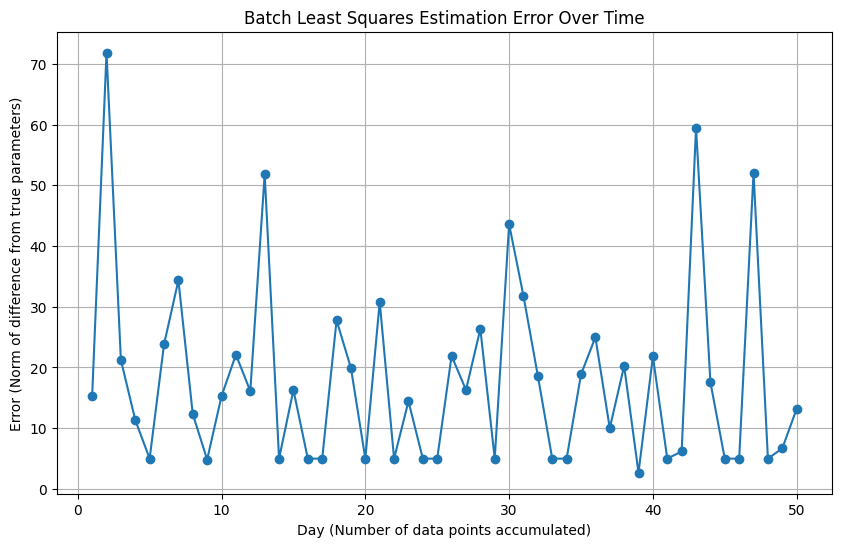

In [8]:
class BatchedLeastSQ:
    def __init__(self, name='BatchedleastSQ_runner'):
        self.name = name
        self.A_mat_st = np.empty((0, 5)) # Assuming 5 parameters: T_baseline, W, B_Coach A, B_Coach B, B_Coach C
        self.b_vec_st = np.empty((0, 1))
        self.param_names = ['T_baseline', 'W', 'B_Coach A', 'B_Coach B', 'B_Coach C'] # Hardcode for initial clarity
        self.estimates_history = []
        self.error_history = []

    def update_batch(self, A_new, b_new, true_params):
        # Accumulate new data
        self.A_mat_st = np.concatenate((self.A_mat_st, A_new), axis=0)
        self.b_vec_st = np.concatenate((self.b_vec_st, b_new), axis=0)

        # Perform Batch LS estimation if enough data
        if self.A_mat_st.shape[0] >= self.A_mat_st.shape[1]: # Number of observations >= number of parameters
            try:
                # (A_stack.T @ A_stack) must be invertible for direct inverse method
                ATA = self.A_mat_st.T @ self.A_mat_st
                if np.linalg.det(ATA) == 0:
                    # Fallback to np.linalg.lstsq for singular or ill-conditioned matrices
                    x_batch, _, _, _ = np.linalg.lstsq(self.A_mat_st, self.b_vec_st, rcond=None)
                else:
                    x_batch = np.linalg.inv(ATA) @ self.A_mat_st.T @ self.b_vec_st

                self.estimates_history.append(x_batch)
                # Calculate error
                error = np.linalg.norm(x_batch - true_params)
                self.error_history.append(error)
            except np.linalg.LinAlgError as e:
                print(f"Batch LS estimation failed: {e}. Skipping this update.")
                self.estimates_history.append(np.full((len(self.param_names), 1), np.nan))
                self.error_history.append(np.nan)
        else:
            # Not enough observations to solve for all parameters yet
            self.estimates_history.append(np.full((len(self.param_names), 1), np.nan))
            self.error_history.append(np.nan)

    def get_last_estimate(self):
        if self.estimates_history:
            return self.estimates_history[-1]
        return None

    def get_estimate_history(self):
        return np.array(self.estimates_history).squeeze()

    def get_error_history(self):
        return np.array(self.error_history)


# --- Simulation and Batch LS Application ---

# True parameters for error calculation
true_params_vec = np.array([
    true_baseline_time,
    true_wind_effect_coeff
] + list(true_coach_biases.values())).reshape(-1, 1)

batch_estimator = BatchedLeastSQ()

# Run Batch LS day by day
for day in range(1, num_days_to_simulate + 1):
    df_current_day = df_all_data[df_all_data['day'] == day]
    A_current_day, b_current_day, _ = construct_A_b(df_current_day, coach_names)
    batch_estimator.update_batch(A_current_day, b_current_day, true_params_vec)

# Display results
batch_estimates = batch_estimator.get_estimate_history()
batch_errors = batch_estimator.get_error_history()

print(f"\nFinal Batch LS Estimates after {num_days_to_simulate} days:")
for i, param in enumerate(param_names):
    print(f"{param}: {batch_estimates[-1, i]:.4f}")

print("\nTrue Parameters:")
print(f"T_baseline: {true_baseline_time}")
print(f"W: {true_wind_effect_coeff}")
for coach, bias in true_coach_biases.items():
    print(f"B_{coach}: {bias}")

print(f"\nFinal Batch LS Estimation Error: {batch_errors[-1]:.4f}")

# Plotting the error convergence
plt.figure(figsize=(10, 6))
plt.plot(range(1, num_days_to_simulate + 1), batch_errors, marker='o', linestyle='-')
plt.title('Batch Least Squares Estimation Error Over Time')
plt.xlabel('Day (Number of data points accumulated)')
plt.ylabel('Error (Norm of difference from true parameters)')
plt.grid(True)
plt.show()


## Recursive Least Squares (RLS)

As we saw with Batch Least Squares, combining all past data improves estimation accuracy. However, continuously restacking and re-inverting large matrices can be computationally expensive and memory-intensive, especially as the amount of data grows indefinitely (e.g., in real-time applications).

**Recursive Least Squares (RLS)** provides an elegant solution to this problem. Instead of recalculating the entire estimate from scratch every time a new data point arrives, RLS updates the previous estimate using only the new observation. This 'recursive' nature makes it efficient for online processing and situations where parameters might slowly change over time.

The core idea behind RLS is to maintain an estimate of the inverse of the $\mathbf{A}^T\mathbf{A}$ matrix (often denoted as $\mathbf{P}$) and the $\mathbf{A}^T\mathbf{b}$ vector (often denoted as $\mathbf{q}$), and then update these recursively with each new measurement.

This method not only saves computational resources but also forms the foundation for more advanced filtering techniques like the Kalman Filter, which we can use when the parameters themselves are expected to change dynamically over time (e.g., if the runner's baseline performance is improving daily).

### Recursive Least Squares Math

Let's start by recalling the Batch LS solution written in terms of $\mathbf{S}_K = \sum_{i=1}^{K} \mathbf{A}_i^T \mathbf{A}_i$ and $\mathbf{q}_K = \sum_{i=1}^{K} \mathbf{A}_i^T \mathbf{b}_i$:

$$ \hat{\mathbf{x}}_K = \mathbf{S}_K^{-1} \mathbf{q}_K = \mathbf{P}_K \mathbf{q}_K $$

Where $\mathbf{P}_K = \mathbf{S}_K^{-1}$.

When a new observation arrives at step $K+1$, consisting of $\mathbf{A}_{K+1}$ (a single row vector) and $\mathbf{b}_{K+1}$ (a single scalar), we can update $\mathbf{S}$ and $\mathbf{q}$ recursively:

$$ \mathbf{S}_{K+1} = \mathbf{S}_K + \mathbf{A}_{K+1}^T \mathbf{A}_{K+1} $$

$$ \mathbf{q}_{K+1} = \mathbf{q}_K + \mathbf{A}_{K+1}^T \mathbf{b}_{K+1} $$

The challenge is to efficiently compute the new inverse $\mathbf{P}_{K+1} = \mathbf{S}_{K+1}^{-1}$ without re-inverting the entire matrix. This is where the **Woodbury Matrix Identity** (also known as the Sherman–Morrison–Woodbury formula) becomes incredibly useful:

For matrices $\mathbf{P}$, $\mathbf{H}$, and $\mathbf{R}$ where $\mathbf{P}^{-1}$ and $(\mathbf{R} + \mathbf{H} \mathbf{P} \mathbf{H}^T)^{-1}$ exist:

$$ (\mathbf{P} + \mathbf{H}^T \mathbf{R}^{-1} \mathbf{H})^{-1} = \mathbf{P}^{-1} - \mathbf{P}^{-1} \mathbf{H}^T (\mathbf{R} + \mathbf{H} \mathbf{P}^{-1} \mathbf{H}^T)^{-1} \mathbf{H} \mathbf{P}^{-1} $$

Applying this identity to find $\mathbf{P}_{K+1} = (\mathbf{S}_K + \mathbf{A}_{K+1}^T \mathbf{A}_{K+1})^{-1}$, let:

*   $\mathbf{P} = \mathbf{S}_K^{-1} = \mathbf{P}_K$
*   $\mathbf{H}^T = \mathbf{A}_{K+1}^T$ (so $\mathbf{H} = \mathbf{A}_{K+1}$)
*   $\mathbf{R}^{-1} = \mathbf{I}$ (a $1 \times 1$ identity matrix, as $\mathbf{A}_{K+1}^T \mathbf{A}_{K+1}$ is a rank-1 update; essentially the scalar 1, representing the weighting of the new measurement contribution)

Then the update for $\mathbf{P}$ becomes:

$$ \mathbf{P}_{K+1} = \mathbf{P}_K - \mathbf{P}_K \mathbf{A}_{K+1}^T (\mathbf{I} + \mathbf{A}_{K+1} \mathbf{P}_K \mathbf{A}_{K+1}^T)^{-1} \mathbf{A}_{K+1} \mathbf{P}_K $$

And finally, the update for the estimate $\hat{\mathbf{x}}_{K+1}$ is:

$$ \hat{\mathbf{x}}_{K+1} = \hat{\mathbf{x}}_K + \mathbf{K}_{K+1} (\mathbf{b}_{K+1} - \mathbf{A}_{K+1} \hat{\mathbf{x}}_K) $$

Where $\mathbf{K}_{K+1}$ is the Kalman gain-like term for RLS:

$$ \mathbf{K}_{K+1} = \mathbf{P}_{K+1} \mathbf{A}_{K+1}^T = \mathbf{P}_K \mathbf{A}_{K+1}^T (\mathbf{I} + \mathbf{A}_{K+1} \mathbf{P}_K \mathbf{A}_{K+1}^T)^{-1} $$

This set of equations allows us to update our estimates iteratively, day by day, or run by run, without re-processing all historical data. The term $(\mathbf{b}_{K+1} - \mathbf{A}_{K+1} \hat{\mathbf{x}}_K)$ represents the residual or innovation—the difference between the actual new measurement and what the current model predicted.

### Incorporating Forgetting Factor (Weighted RLS)

Often, in real-world scenarios, the true underlying parameters might not be constant but instead change slowly over time. For example, our runner's baseline performance might improve, or coaches' biases could drift. To account for this, RLS can be extended with a **forgetting factor** ($\lambda$, where $0 < \lambda \le 1$).

The forgetting factor gives more weight to recent data and gradually 'forgets' older data. This is achieved by modifying the updates for $\mathbf{S}$ and $\mathbf{q}$:

$$ \mathbf{S}_{K+1} = \lambda \mathbf{S}_K + \mathbf{A}_{K+1}^T \mathbf{A}_{K+1} $$

$$ \mathbf{q}_{K+1} = \lambda \mathbf{q}_K + \mathbf{A}_{K+1}^T \mathbf{b}_{K+1} $$

And consequently, the update for $\mathbf{P}$ becomes:

$$ \mathbf{P}_{K+1} = (\lambda \mathbf{P}_K^{-1} + \mathbf{A}_{K+1}^T \mathbf{A}_{K+1})^{-1} $$

Which, using the Woodbury identity, can be rewritten as:

$$ \mathbf{P}_{K+1} = \frac{1}{\lambda} \left( \mathbf{P}_K - \mathbf{P}_K \mathbf{A}_{K+1}^T \left(\lambda \mathbf{I} + \mathbf{A}_{K+1} \mathbf{P}_K \mathbf{A}_{K+1}^T\right)^{-1} \mathbf{A}_{K+1} \mathbf{P}_K \right) $$

And the gain term:

$$ \mathbf{K}_{K+1} = \mathbf{P}_K \mathbf{A}_{K+1}^T (\lambda \mathbf{I} + \mathbf{A}_{K+1} \mathbf{P}_K \mathbf{A}_{K+1}^T)^{-1} $$

If $\lambda=1$, this is standard RLS. If $\lambda < 1$, older data has less influence. A common practice is to initialize $\mathbf{P}_0$ with a large value (e.g., $10^3 \cdot \mathbf{I}$) to reflect high initial uncertainty in the parameters.

### RLS for Runner Timing Simulation

Now, we'll implement the RLS algorithm to track our runner's performance parameters. We will process the daily observations sequentially, updating our estimates each day. This will allow us to observe how the estimates evolve and converge over time, similar to batch LS, but with a more computationally efficient approach for streaming data.

We will use a forgetting factor ($\lambda$) to see how it affects the tracking of potentially changing parameters. For our current simulation, the true parameters are constant, so a $\lambda=1$ (no forgetting) should ideally yield results similar to batch LS as the number of days increases. However, if the runner's baseline was actually improving, a $\lambda < 1$ would be beneficial.

Let's apply the RLS to our simulated daily data.

To conclude, RLS is one of many recursive methods for solving the least squares. It also provides a foundation to the kalman filter, which can be used instead if the target is moving and the parameters themselves are modeled dynamically.


Final RLS Estimates after 50 days (lambda=0.98):
T_baseline: 7.5143
W: -0.0995
B_Coach A: 2.5880
B_Coach B: 2.4385
B_Coach C: 2.4877

True Parameters:
T_baseline: 10.0
W: -0.1
B_Coach A: 0.1
B_Coach B: -0.05
B_Coach C: 0.0

Final RLS Estimation Error: 4.9750


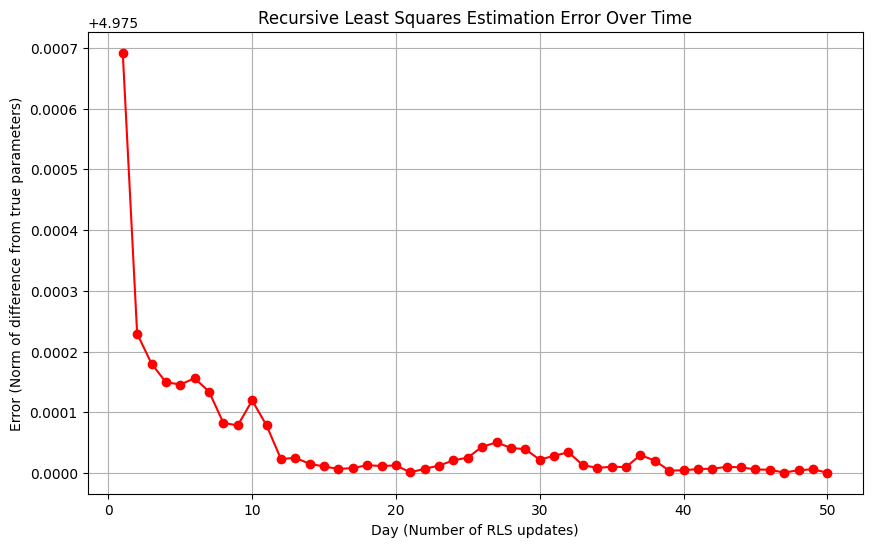

In [9]:
class RecursiveLeastSQ:
    def __init__(self, lambda_=1.0, P0_diag=1e3, name='RecursiveLeastSQ_runner'):
        # lambda_: forgetting factor (0 < lambda_ <= 1)
        # P0_diag: initial diagonal value for P matrix (large value for high initial uncertainty)
        self.name = name
        self.lambda_ = lambda_

        # Number of parameters (T_baseline, W, B_Coach A, B_Coach B, B_Coach C)
        self.num_params = 5

        # Initialize P_k (inverse of S_k) with a large covariance to reflect high initial uncertainty
        self.P_k = P0_diag * np.eye(self.num_params)

        # Initialize x_k (parameter estimate) to zeros or a reasonable prior
        self.x_k = np.zeros((self.num_params, 1))

        self.estimates_history = []
        self.error_history = []
        self.param_names = ['T_baseline', 'W', 'B_Coach A', 'B_Coach B', 'B_Coach C']

    def update(self, A_new, b_new, true_params):
        # A_new: single row (1 x num_params) or multiple rows (num_runs_day x num_params) for a given day
        # b_new: single value (1 x 1) or multiple values (num_runs_day x 1) for a given day

        # To process a day's worth of data as a 'batch' within one RLS step (effectively treating it as multiple sequential updates)
        # It's more common to process one observation at a time for true RLS, but for daily data, we can iterate.

        current_P = self.P_k.copy()
        current_x = self.x_k.copy()

        for i in range(A_new.shape[0]):
            A_i = A_new[i:i+1, :]
            b_i = b_new[i:i+1, :]

            # Calculate Kalman Gain-like term K_k+1
            # Denominator: (lambda * I + A_i * P_k * A_i.T)
            denominator = self.lambda_ * np.eye(A_i.shape[0]) + A_i @ current_P @ A_i.T
            K_k1 = current_P @ A_i.T @ np.linalg.inv(denominator)

            # Update parameter estimate x_k+1
            current_x = current_x + K_k1 @ (b_i - A_i @ current_x)

            # Update P_k+1
            current_P = (current_P - K_k1 @ A_i @ current_P) / self.lambda_

        # Store the updated state for the end of the day
        self.P_k = current_P
        self.x_k = current_x

        self.estimates_history.append(self.x_k)
        error = np.linalg.norm(self.x_k - true_params)
        self.error_history.append(error)

    def get_last_estimate(self):
        if self.estimates_history:
            return self.estimates_history[-1]
        return None

    def get_estimate_history(self):
        return np.array(self.estimates_history).squeeze()

    def get_error_history(self):
        return np.array(self.error_history)


# --- Simulation and RLS Application ---

# True parameters for error calculation
true_params_vec = np.array([
    true_baseline_time,
    true_wind_effect_coeff
] + list(true_coach_biases.values())).reshape(-1, 1)

rls_estimator = RecursiveLeastSQ(lambda_=0.98, P0_diag=1e3) # Using a forgetting factor of 0.98

# Run RLS day by day
for day in range(1, num_days_to_simulate + 1):
    df_current_day = df_all_data[df_all_data['day'] == day]
    A_current_day, b_current_day, _ = construct_A_b(df_current_day, coach_names)
    rls_estimator.update(A_current_day, b_current_day, true_params_vec)

# Display results
rls_estimates = rls_estimator.get_estimate_history()
rls_errors = rls_estimator.get_error_history()

print(f"\nFinal RLS Estimates after {num_days_to_simulate} days (lambda={rls_estimator.lambda_}):")
for i, param in enumerate(param_names):
    print(f"{param}: {rls_estimates[-1, i]:.4f}")

print("\nTrue Parameters:")
print(f"T_baseline: {true_baseline_time}")
print(f"W: {true_wind_effect_coeff}")
for coach, bias in true_coach_biases.items():
    print(f"B_{coach}: {bias}")

print(f"\nFinal RLS Estimation Error: {rls_errors[-1]:.4f}")

# Plotting the error convergence
plt.figure(figsize=(10, 6))
plt.plot(range(1, num_days_to_simulate + 1), rls_errors, marker='o', linestyle='-', color='red')
plt.title('Recursive Least Squares Estimation Error Over Time')
plt.xlabel('Day (Number of RLS updates)')
plt.ylabel('Error (Norm of difference from true parameters)')
plt.grid(True)
plt.show()


### Comparing Batch LS and RLS Convergence

Let's plot the errors from both Batch LS and RLS on the same graph to visualize their convergence and performance.

We would expect both methods to converge to similar estimates for constant parameters as the amount of data increases, assuming an appropriate forgetting factor (like $\lambda=1$ or close to 1 for RLS). RLS might show a slightly different convergence path due to its sequential updating nature and the impact of the forgetting factor and initial conditions.

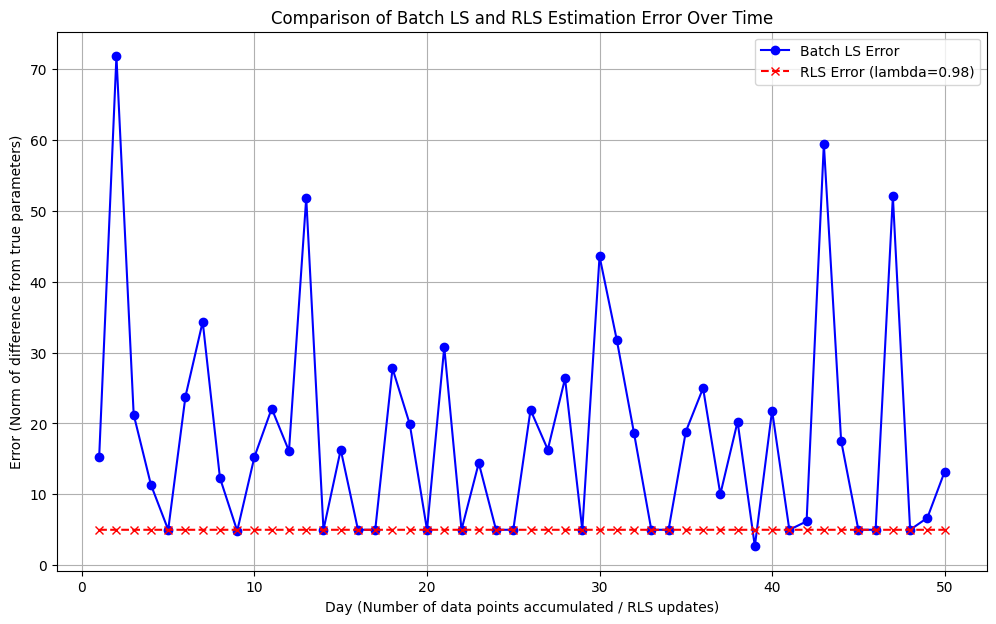

In [10]:
# Plotting Batch LS and RLS error convergence together
plt.figure(figsize=(12, 7))

plt.plot(range(1, num_days_to_simulate + 1), batch_errors, marker='o', linestyle='-', label='Batch LS Error', color='blue')
plt.plot(range(1, num_days_to_simulate + 1), rls_errors, marker='x', linestyle='--', label=f'RLS Error (lambda={rls_estimator.lambda_})', color='red')

plt.title('Comparison of Batch LS and RLS Estimation Error Over Time')
plt.xlabel('Day (Number of data points accumulated / RLS updates)')
plt.ylabel('Error (Norm of difference from true parameters)')
plt.legend()
plt.grid(True)
plt.show()


## Resources

Here are some resources for further learning about Least Squares and Recursive Least Squares:

*   **Books:**
    *   "Optimal Filtering" by Brian D.O. Anderson and John B. Moore
    *   "Kalman Filtering and Neural Networks" edited by Simon Haykin
    *   "Linear Algebra and Its Applications" by Gilbert Strang

*   **Online Courses & Tutorials:**
    *   Coursera: "Linear Algebra for Machine Learning and Data Science"
    *   MIT OpenCourseware: "Linear Algebra (18.06)"
    *   Various online tutorials on RLS and Kalman filters (e.g., from academic institutions or engineering blogs).

*   **Python Libraries:**
    *   `numpy.linalg.lstsq` for standard Least Squares.
    *   Implementations of RLS and Kalman filters can be found in specialized libraries or often implemented from scratch for educational purposes.

*   **Advanced Topics:**
    *   **Proof of optimality for Gaussian residuals:** Explore the statistical properties of LS under assumptions of Gaussian measurement noise, leading to maximum likelihood estimation.
    *   **Extension to nonlinear features:** Discuss how basis functions can be used to model nonlinear relationships while keeping the problem linear in the parameters (e.g., polynomial regression).
    *   **Tricks for estimating some nonlinear parameters:** Introduce iterative methods like Gauss-Newton or Levenberg-Marquardt for truly nonlinear LS problems.
    *   **Estimating coach's measurement bias:** Consider how additional parameters for each coach's bias would expand the design matrix $\mathbf{A}$. For example, if wind speed was directional (e.g., headwind vs. tailwind), you might have two separate parameters impacting the time, one for each direction, adding columns to the $\mathbf{A}$ matrix.

This tutorial primarily focuses on deriving RLS from LS, but these are just a few directions to explore the broad applications and theoretical underpinnings of these powerful estimation techniques.

In [ ]:
## INITIALIZE CONTROLLER
rng = np.random.default_rng(10)
mc_count = 1000
## TODO, Controller should take in environment, and run environment setup here, rather than manually
#        affecting the sensor relocation earlier in this main script
myController = controller.Controller(mySeizure,
                                    sensor_list,
                                    myEstimator,
                                    mc_count = mc_count, rng=rng)
myController.run_simulation()

## References

[1] C. Wang, W. Fu, T. Zhang, M. Zeng, and H. Cheng, “An AOA Optimal Positioning Method Incorporating Station Error and Sensor Deployment,” Aerospace, vol. 9, no. 12, pp. 766–766, Nov. 2022, doi: https://doi.org/10.3390/aerospace9120766  
[22] D. Torrieri, “Statistical Theory of Passive Location Systems,” IEEE Trans. Aerosp. Electron. Syst., vol. AES-20, no. 2, pp. 183–198, Mar. 1984, doi: 10.1109/TAES.1984.310439. [24] https://ieeexplore.ieee.org/stamp/stamp.jsp?tp=&arnumber=1045433